# Stage 06 — WANDS Dataset Exploration

This notebook performs descriptive exploration of the **actual local WANDS files**.

It does not train models and does not modify raw data.

Files expected:

```text
data/raw/wands/
├── product.csv
├── query.csv
└── label.csv
```

All statistics in this notebook are measured from the local dataset when the notebook is executed.


In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()

# Allow execution either from the repository root or from notebooks/.
if (ROOT / "data/raw/wands").exists():
    PROJECT_ROOT = ROOT
elif (ROOT.parent / "data/raw/wands").exists():
    PROJECT_ROOT = ROOT.parent
else:
    raise FileNotFoundError(
        "Could not locate data/raw/wands. Run this notebook from the "
        "RelevanceFlow repository or notebooks/ directory."
    )

DATA_DIR = PROJECT_ROOT / "data/raw/wands"

PRODUCT_PATH = DATA_DIR / "product.csv"
QUERY_PATH = DATA_DIR / "query.csv"
LABEL_PATH = DATA_DIR / "label.csv"

for path in (PRODUCT_PATH, QUERY_PATH, LABEL_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Missing WANDS file: {path}")

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)


Project root: d:\RelevanceFlow
Dataset directory: d:\RelevanceFlow\data\raw\wands


In [3]:
product_df = pd.read_csv(PRODUCT_PATH, sep='\t')
query_df = pd.read_csv(QUERY_PATH, sep='\t')
label_df = pd.read_csv(LABEL_PATH, sep='\t')

print("Product shape:", product_df.shape)
print("Query shape:", query_df.shape)
print("Label shape:", label_df.shape)


Product shape: (42994, 9)
Query shape: (480, 3)
Label shape: (233448, 4)


## 1. Schema overview

In [4]:
print("PRODUCT COLUMNS")
display(pd.DataFrame({
    "column": product_df.columns,
    "dtype": product_df.dtypes.astype(str).values,
    "missing": product_df.isna().sum().values,
    "missing_pct": (product_df.isna().mean() * 100).round(2).values,
}))

print("\nQUERY COLUMNS")
display(pd.DataFrame({
    "column": query_df.columns,
    "dtype": query_df.dtypes.astype(str).values,
    "missing": query_df.isna().sum().values,
    "missing_pct": (query_df.isna().mean() * 100).round(2).values,
}))

print("\nLABEL COLUMNS")
display(pd.DataFrame({
    "column": label_df.columns,
    "dtype": label_df.dtypes.astype(str).values,
    "missing": label_df.isna().sum().values,
    "missing_pct": (label_df.isna().mean() * 100).round(2).values,
}))


PRODUCT COLUMNS


,column,dtype,missing,missing_pct
0,product_id,int64,0,0.00
1,product_name,str,0,0.00
2,product_class,str,2852,6.63
3,category hierarchy,str,1556,3.62
4,product_description,str,6008,13.97
5,product_features,str,0,0.00
6,rating_count,float64,9452,21.98
7,average_rating,float64,9452,21.98
8,review_count,float64,9452,21.98



QUERY COLUMNS


,column,dtype,missing,missing_pct
0,query_id,int64,0,0.00
1,query,str,0,0.00
2,query_class,str,6,1.25



LABEL COLUMNS


,column,dtype,missing,missing_pct
0,id,int64,0,0.0
1,query_id,int64,0,0.0
2,product_id,int64,0,0.0
3,label,str,0,0.0


## 2. Query statistics

In [5]:
def word_count(value: object) -> int:
    if pd.isna(value):
        return 0
    return len(re.findall(r"\S+", str(value).strip()))

def char_count(value: object) -> int:
    if pd.isna(value):
        return 0
    return len(str(value).strip())

query_df = query_df.copy()
query_df["query_word_count"] = query_df["query"].map(word_count)
query_df["query_char_count"] = query_df["query"].map(char_count)

print("Number of unique query IDs:", query_df["query_id"].nunique())
print("Number of query rows:", len(query_df))
print("Duplicate query IDs:", query_df["query_id"].duplicated().sum())
print("Duplicate query text:", query_df["query"].duplicated().sum())
print("Unique query text:", query_df["query"].nunique())

print("\nQuery word-count statistics:")
display(query_df["query_word_count"].describe())

print("\nQuery character-count statistics:")
display(query_df["query_char_count"].describe())

print("\nQuery classes:")
display(query_df["query_class"].value_counts(dropna=False).to_frame("count"))

print("\nExact duplicate query texts:")
duplicate_queries = (
    query_df[query_df["query"].duplicated(keep=False)]
    .sort_values("query")
)
display(duplicate_queries.head(50))


Number of unique query IDs: 480
Number of query rows: 480
Duplicate query IDs: 0
Duplicate query text: 0
Unique query text: 480

Query word-count statistics:


count    480.000000
mean       3.381250
std        1.495457
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       10.000000
Name: query_word_count, dtype: float64


Query character-count statistics:


count    480.000000
mean      20.979167
std        9.211252
min        3.000000
25%       14.000000
50%       20.000000
75%       25.000000
max       67.000000
Name: query_char_count, dtype: float64


Query classes:


,count
query_class,
Wall Art,20
Accent Chairs,16
Beds,15
Area Rugs,15
Coffee & Cocktail Tables,10
...,...
Flatware Serving Pieces,1
Swing Set Accessories,1
Bike And Sport Racks,1



Exact duplicate query texts:


,query_id,query,query_class,query_word_count,query_char_count


## 3. Product statistics

In [6]:
product_df = product_df.copy()

text_columns = [
    "product_name",
    "product_description",
    "product_features",
    "category_hierarchy",
]

for column in text_columns:
    if column in product_df.columns:
        product_df[f"{column}_word_count"] = product_df[column].map(word_count)
        product_df[f"{column}_char_count"] = product_df[column].map(char_count)

print("Number of product rows:", len(product_df))
print("Unique product IDs:", product_df["product_id"].nunique())
print("Duplicate product IDs:", product_df["product_id"].duplicated().sum())

print("\nProduct classes:")
display(product_df["product_class"].value_counts(dropna=False).to_frame("count"))

missing_product_fields = pd.DataFrame({
    "missing_count": product_df.isna().sum(),
    "missing_pct": (product_df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)

print("\nProduct missing-value summary:")
display(missing_product_fields)

if "category_hierarchy" in product_df.columns:
    print("\nTop category_hierarchy values:")
    display(product_df["category_hierarchy"].value_counts(dropna=False).head(25).to_frame("count"))

print("\nRating statistics:")
rating_columns = [c for c in ["average_rating", "rating_count", "review_count"] if c in product_df]
display(product_df[rating_columns].describe().T)


Number of product rows: 42994
Unique product IDs: 42994
Duplicate product IDs: 0

Product classes:


,count
product_class,
NaN,2852
Area Rugs,1316
Accent Chairs,1169
Beds,1112
Coffee & Cocktail Tables,1085
...,...
Massage Therapy Products|Massage Chairs,1
Licensed Products|End Tables,1
Laundry Accessories,1



Product missing-value summary:


,missing_count,missing_pct
rating_count,9452,21.98
review_count,9452,21.98
average_rating,9452,21.98
product_description,6008,13.97
product_class,2852,6.63
category hierarchy,1556,3.62
product_id,0,0.00
product_features,0,0.00
product_name,0,0.00
product_name_word_count,0,0.00



Rating statistics:


,count,mean,std,min,25%,50%,75%,max
average_rating,33542.0,4.530126,0.509263,1.0,4.5,4.5,5.0,5.0
rating_count,33542.0,430.270437,2407.921579,1.0,8.0,42.0,195.0,109226.0
review_count,33542.0,284.250343,1539.611737,0.0,6.0,31.0,131.0,61362.0


## 4. Product text-length statistics

In [7]:
product_length_columns = [
    column
    for column in [
        "product_name_word_count",
        "product_description_word_count",
        "product_features_word_count",
    ]
    if column in product_df.columns
]

display(product_df[product_length_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
product_name_word_count,42994.0,6.754291,3.808454,1.0,4.0,6.0,8.0,49.0
product_description_word_count,42994.0,71.421361,58.408903,0.0,33.0,65.0,96.0,791.0
product_features_word_count,42994.0,120.497511,65.597949,1.0,77.0,112.0,154.0,2537.0


## 5. Judgment statistics

In [8]:
label_df = label_df.copy()

print("Judgment rows:", len(label_df))
print("Unique judgment IDs:", label_df["id"].nunique())
print("Duplicate judgment IDs:", label_df["id"].duplicated().sum())
print("Duplicate query-product pairs:",
      label_df.duplicated(["query_id", "product_id"]).sum())

print("\nLabel distribution:")
label_counts = label_df["label"].value_counts(dropna=False)
label_distribution = pd.DataFrame({
    "count": label_counts,
    "percentage": (label_counts / len(label_df) * 100).round(2),
})
display(label_distribution)

print("\nLabel values:")
display(pd.Series(sorted(label_df["label"].dropna().unique()), name="label"))

judgments_per_query = label_df.groupby("query_id").size()

print("\nJudgments per query:")
display(judgments_per_query.describe().to_frame("judgments_per_query"))

products_per_query = label_df.groupby("query_id")["product_id"].nunique()

print("\nUnique products per query:")
display(products_per_query.describe().to_frame("products_per_query"))


Judgment rows: 233448
Unique judgment IDs: 233448
Duplicate judgment IDs: 0
Duplicate query-product pairs: 1575

Label distribution:


,count,percentage
label,,
Partial,146633,62.81
Irrelevant,61201,26.22
Exact,25614,10.97



Label values:


0         Exact
1    Irrelevant
2       Partial
Name: label, dtype: str


Judgments per query:


,judgments_per_query
count,480.000000
mean,486.350000
std,708.524261
min,1.000000
25%,122.750000
50%,216.500000
75%,523.750000
max,4329.000000



Unique products per query:


,products_per_query
count,480.00000
mean,483.06875
std,707.71258
min,1.00000
25%,122.00000
50%,215.00000
75%,504.25000
max,4329.00000


## 6. Referential integrity

In [9]:
unknown_products = (~label_df["product_id"].isin(product_df["product_id"])).sum()
unknown_queries = (~label_df["query_id"].isin(query_df["query_id"])).sum()

print("Judgments referencing unknown products:", unknown_products)
print("Judgments referencing unknown queries:", unknown_queries)

print("\nNull counts in labels:")
display(label_df.isna().sum().to_frame("missing"))


Judgments referencing unknown products: 0
Judgments referencing unknown queries: 0

Null counts in labels:


,missing
id,0
query_id,0
product_id,0
label,0


## 7. Query-level exploration

In [10]:
query_summary = (
    label_df.groupby("query_id")
    .agg(
        judgments=("product_id", "size"),
        unique_products=("product_id", "nunique"),
        exact_count=("label", lambda s: (s == "Exact").sum()),
        partial_count=("label", lambda s: (s == "Partial").sum()),
        irrelevant_count=("label", lambda s: (s == "Irrelevant").sum()),
    )
    .join(query_df.set_index("query_id")[["query", "query_class", "query_word_count"]])
    .reset_index()
)

display(query_summary.head())

print("Queries with no Exact judgments:",
      (query_summary["exact_count"] == 0).sum())

print("Queries with no Partial judgments:",
      (query_summary["partial_count"] == 0).sum())


,query_id,judgments,unique_products,exact_count,partial_count,irrelevant_count,query,query_class,query_word_count
0,0,3303,3302,39,2977,287,salon chair,Massage Chairs,2
1,1,1436,1436,8,1410,18,smart coffee table,Coffee & Cocktail Tables,3
2,2,165,165,151,7,7,dinosaur,Kids Wall Décor,1
3,3,997,997,55,717,225,turquoise pillows,Accent Pillows,2
4,4,240,239,23,168,49,chair and a half recliner,Recliners,5


Queries with no Exact judgments: 101
Queries with no Partial judgments: 12


## 8. Visualizations

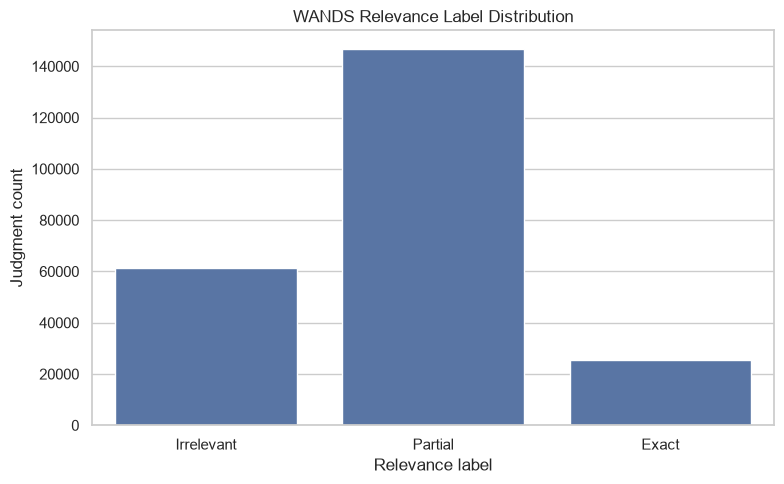

In [11]:
sns.set_theme(style="whitegrid")

# 1. Label distribution
plt.figure(figsize=(8, 5))
order = ["Irrelevant", "Partial", "Exact"]
sns.countplot(data=label_df, x="label", order=[x for x in order if x in label_df["label"].unique()])
plt.title("WANDS Relevance Label Distribution")
plt.xlabel("Relevance label")
plt.ylabel("Judgment count")
plt.tight_layout()
plt.show()


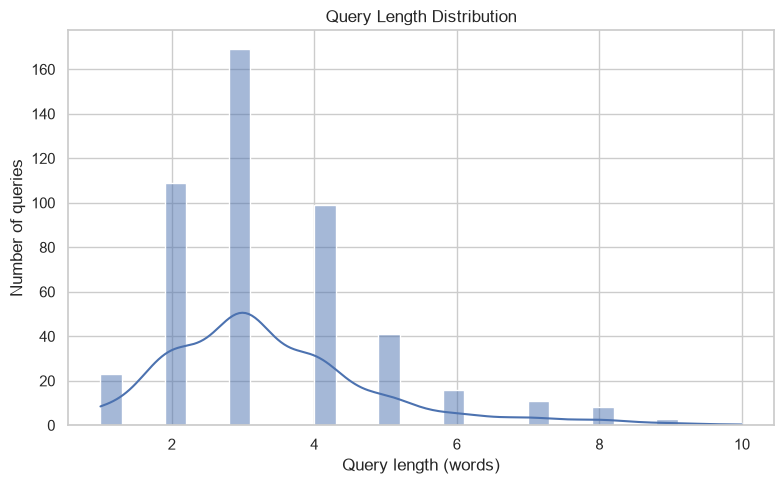

In [12]:
# 2. Query length distribution
plt.figure(figsize=(8, 5))
sns.histplot(query_df["query_word_count"], bins=30, kde=True)
plt.title("Query Length Distribution")
plt.xlabel("Query length (words)")
plt.ylabel("Number of queries")
plt.tight_layout()
plt.show()


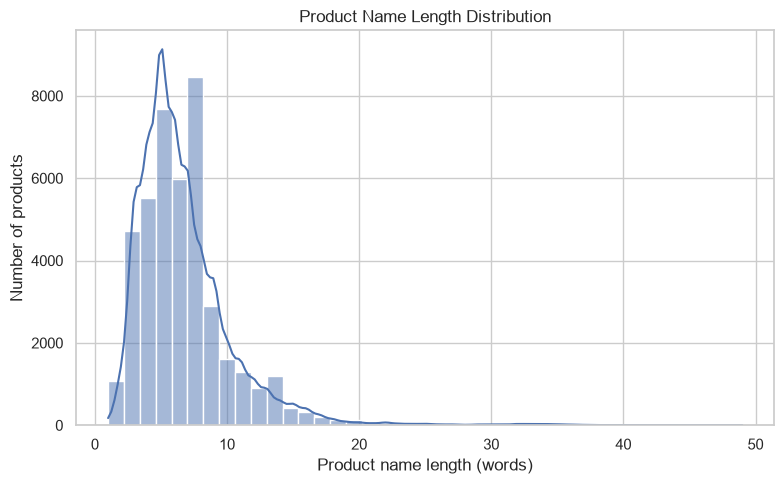

In [13]:
# 3. Product length distribution
length_column = "product_name_word_count"

plt.figure(figsize=(8, 5))
sns.histplot(product_df[length_column], bins=40, kde=True)
plt.title("Product Name Length Distribution")
plt.xlabel("Product name length (words)")
plt.ylabel("Number of products")
plt.tight_layout()
plt.show()


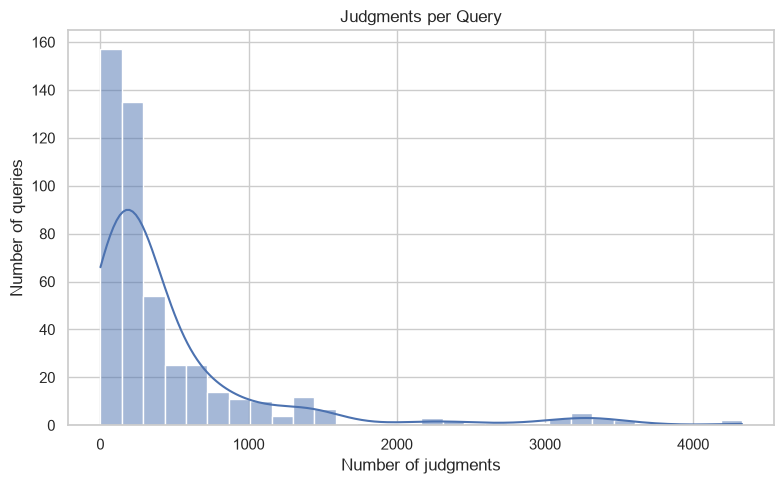

In [14]:
# 4. Judgments per query
plt.figure(figsize=(8, 5))
sns.histplot(judgments_per_query, bins=30, kde=True)
plt.title("Judgments per Query")
plt.xlabel("Number of judgments")
plt.ylabel("Number of queries")
plt.tight_layout()
plt.show()


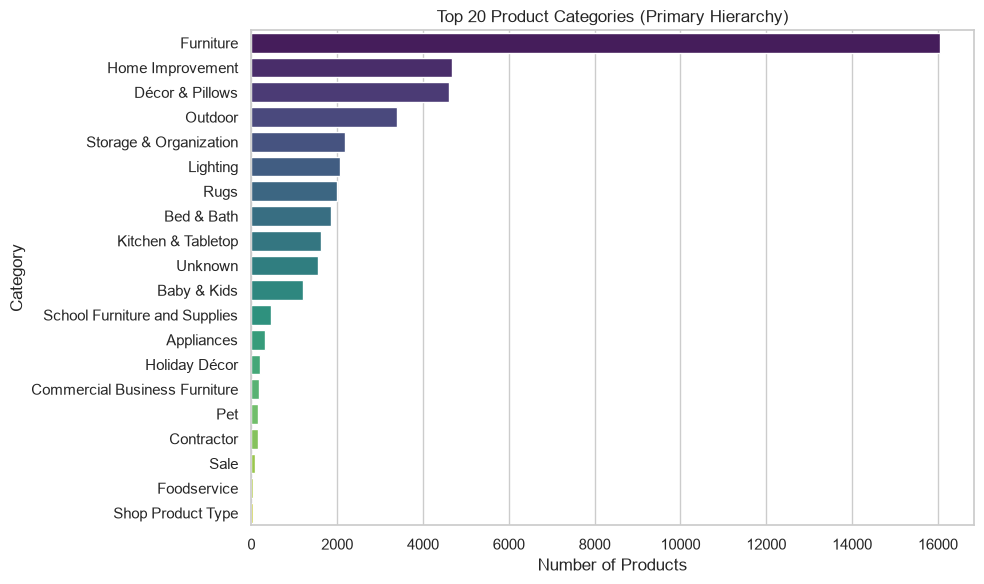

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Standardize column names if not done already
product_df.columns = (
    product_df.columns.str.strip().str.lower().str.replace(" ", "_")
)

# 2. Extract primary category (handles raw lists or slash-separated hierarchy paths)
# e.g., "Home / Furniture / Chairs" -> "Home"
product_df["primary_category"] = (
    product_df["category_hierarchy"]
    .fillna("Unknown")
    .astype(str)
    .apply(lambda x: x.split("/")[0].strip("[]'\" ").strip())
)

# 3. Get top categories
category_counts = (
    product_df["primary_category"].value_counts().head(20).reset_index()
)
category_counts.columns = ["category", "count"]

# 4. Plot distribution (using hue & legend=False to prevent Seaborn deprecation warnings)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_counts,
    x="count",
    y="category",
    hue="category",
    palette="viridis",
    legend=False,
)

plt.title("Top 20 Product Categories (Primary Hierarchy)")
plt.xlabel("Number of Products")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 9. Rating distributions

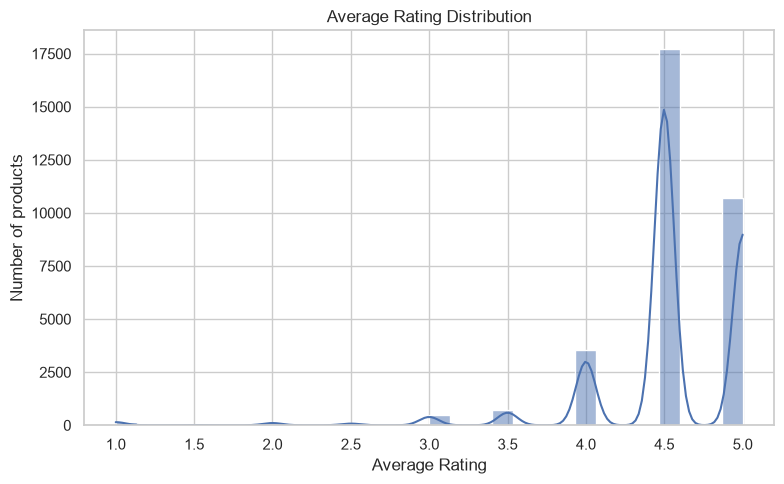

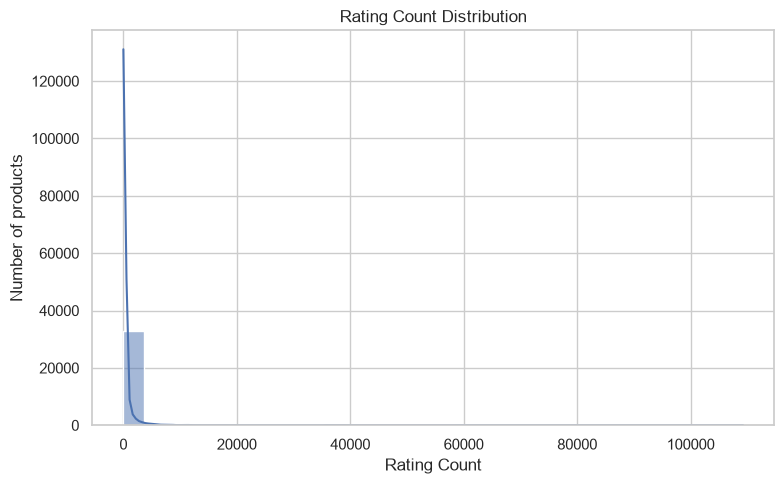

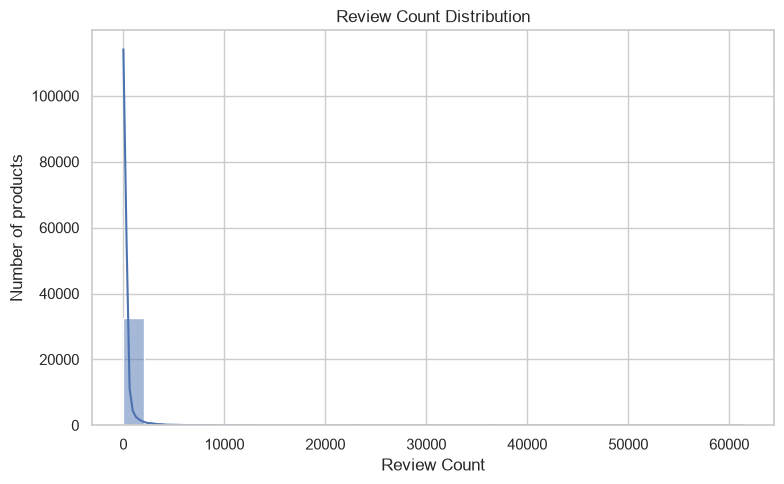

In [20]:
for column in ["average_rating", "rating_count", "review_count"]:
    if column not in product_df.columns:
        continue

    plt.figure(figsize=(8, 5))
    sns.histplot(product_df[column].dropna(), bins=30, kde=True)
    plt.title(f"{column.replace('_', ' ').title()} Distribution")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Number of products")
    plt.tight_layout()
    plt.show()


## 10. Compact exploration report

In [21]:
report = {
    "product_rows": len(product_df),
    "product_columns": int(product_df.shape[1]),
    "unique_products": int(product_df["product_id"].nunique()),
    "duplicate_product_ids": int(product_df["product_id"].duplicated().sum()),
    "query_rows": len(query_df),
    "query_columns": int(query_df.shape[1]),
    "unique_queries": int(query_df["query_id"].nunique()),
    "duplicate_query_ids": int(query_df["query_id"].duplicated().sum()),
    "duplicate_query_text": int(query_df["query"].duplicated().sum()),
    "label_rows": len(label_df),
    "unique_judgments": int(label_df["id"].nunique()),
    "duplicate_judgment_ids": int(label_df["id"].duplicated().sum()),
    "duplicate_query_product_pairs": int(
        label_df.duplicated(["query_id", "product_id"]).sum()
    ),
    "unknown_product_references": int(unknown_products),
    "unknown_query_references": int(unknown_queries),
    "query_word_mean": float(query_df["query_word_count"].mean()),
    "query_word_median": float(query_df["query_word_count"].median()),
    "judgments_per_query_mean": float(judgments_per_query.mean()),
    "judgments_per_query_median": float(judgments_per_query.median()),
    "products_per_query_mean": float(products_per_query.mean()),
    "products_per_query_median": float(products_per_query.median()),
}

display(pd.Series(report, name="value"))


product_rows                      42994.00000
product_columns                      16.00000
unique_products                   42994.00000
duplicate_product_ids                 0.00000
query_rows                          480.00000
query_columns                         5.00000
unique_queries                      480.00000
duplicate_query_ids                   0.00000
duplicate_query_text                  0.00000
label_rows                       233448.00000
unique_judgments                 233448.00000
duplicate_judgment_ids                0.00000
duplicate_query_product_pairs      1575.00000
unknown_product_references            0.00000
unknown_query_references              0.00000
query_word_mean                       3.38125
query_word_median                     3.00000
judgments_per_query_mean            486.35000
judgments_per_query_median          216.50000
products_per_query_mean             483.06875
products_per_query_median           215.00000
Name: value, dtype: float64

In [22]:
# Save measured statistics for reproducibility.
report_dir = PROJECT_ROOT / "reports"
report_dir.mkdir(parents=True, exist_ok=True)

pd.Series(report, name="value").to_csv(
    report_dir / "stage06_exploration_summary.csv",
    header=True,
)

print("Saved:", report_dir / "stage06_exploration_summary.csv")


Saved: d:\RelevanceFlow\reports\stage06_exploration_summary.csv
